In [1]:
#config
import pandas as pd
from pathlib import Path
from src.diagnostics import load_diagnostic_inputs, run_multizone_diagnostics, wape_inflation_report, _spike_threshold_per_zone

ZONES_CMP = ["DK1", "ES", "NO2"]    # order drives the plot legend/colour order
INPUT_DIR  = "results/comparison/inputs"
SAVE_DIR   = "results/comparison/diag_new_multizone"
 

# Part 1 - compare the new model's performance using the same diagnostics as for the old model on the same test set

In [2]:
#load and check windows
long_by_zone = load_diagnostic_inputs(INPUT_DIR, ZONES_CMP)
for z, df in long_by_zone.items():
    
    print(f"{z}: {df['date_time'].min()} -> {df['date_time'].max()}  ({len(df)} h)")

DK1: 2025-06-18 00:00:00 -> 2025-11-26 23:00:00  (3888 h)
ES: 2025-06-20 00:00:00 -> 2025-11-26 23:00:00  (3840 h)
NO2: 2025-06-20 00:00:00 -> 2025-11-26 23:00:00  (3840 h)


**Note: A cross-reference to the diagnostics notebook for the inherited model reveals that it has in total 3 hours missing from the test set of each bidding zone. That is, the test set in the old pipeline for DK1 has 3885 hourly observations, ES and NO2 have 3837 each.**

In [ ]:
base_dir = Path.cwd()

for zone in list(ZONES_CMP):
    
    file_path = base_dir / "inherited_pipeline" / "DsLab25W_marbl.energy" / "summary" / f"old_{zone}_df.parquet"
    
    globals()[f"old+{zone}+_df"] = pd.read_parquet(file_path)
    
    total_days = globals()[f"old+{zone}+_df"]['date'].nunique()

    globals()[f"rows_per_day+{zone}"] = globals()[f"old+{zone}+_df"].groupby('date').size().reset_index(name='row_count')
    
    print("\nNumber of rows for each day:")
    print(globals()[f"rows_per_day+{zone}"]["row_count"].nunique())

    globals()[f"check_rows_per_day+{zone}"] = globals()[f"rows_per_day+{zone}"][globals()[f"rows_per_day+{zone}"]['row_count'] != 24]

    print(zone)
    print("----------------------------------")
    print(globals()[f"check_rows_per_day+{zone}"])


Number of rows for each day:
3
DK1
----------------------------------
          date  row_count
130 2025-10-26         22
161 2025-11-26         23

Number of rows for each day:
3
ES
----------------------------------
          date  row_count
128 2025-10-26         22
159 2025-11-26         23

Number of rows for each day:
3
NO2
----------------------------------
          date  row_count
128 2025-10-26         22
159 2025-11-26         23


**We find these observations in the test set and we remove them to ensure we have the same test set as in the inherited pipeline**

In [4]:
timestamps_to_remove = pd.to_datetime(["2025-11-26 23:00:00", "2025-10-26 00:00:00", "2025-10-26 01:00:00"])

for z, df in long_by_zone.items():

    long_by_zone[z] = df[~df["date_time"].isin(timestamps_to_remove)]

print(f"timestamps {list(timestamps_to_remove)} removed")



timestamps [Timestamp('2025-11-26 23:00:00'), Timestamp('2025-10-26 00:00:00'), Timestamp('2025-10-26 01:00:00')] removed


In [5]:
for z, df in long_by_zone.items():
    print(f"{z}: {df['date_time'].min()} -> {df['date_time'].max()}  ({len(df)} h)")

DK1: 2025-06-18 00:00:00 -> 2025-11-26 22:00:00  (3885 h)
ES: 2025-06-20 00:00:00 -> 2025-11-26 22:00:00  (3837 h)
NO2: 2025-06-20 00:00:00 -> 2025-11-26 22:00:00  (3837 h)


In [6]:
for z,df in long_by_zone.items():
    print(_spike_threshold_per_zone(df))

{'DK1': 146.3}
{'ES': 128.1}
{'NO2': 98.5}


In [7]:

# check if the actual price time series are equal

old_DK1_df = pd.read_parquet(f"D:/WU/Semester 6/Data Science 5/DsLab26W_marbl.energy/DsLab25W_marbl.energy/summary/old_DK1_df.parquet")



try:
    # Try to compare the dataframes
    pd.testing.assert_series_equal(old_DK1_df["price_eur_mwh"], long_by_zone["DK1"]["actual"], atol=1e-1, check_freq=False, check_index=False)
    
    # If the line above succeeds, it moves to this line
    print("PARITY OK")

except AssertionError as e:
    # If the assertion fails, it jumps here instead of crashing your script
    print(" PARITY FAILED!")
    print(f"Details: {e}")

 PARITY FAILED!
Details: Series are different

Series values are different (0.1287 %)
[index]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]
[left]:  [101.5, 95.84, 97.01, 94.12, 112.35, 114.9, 111.39, 78.97, 21.77, 1.17, -0.12, -0.27, -0.21, -0.3, 0.99, 52.16, 68.9, 88.96, 120.4, 115.68, 109.55, 87.56, 111.79, 95.17, 100.17, 87.29, 70.23, 74.35, 78.99, 72.51, 50.0, 0.86, -1.33, -8.27, -5.36, -4.97, -5.09, -6.0, -4.95, 2.3, 80.33, 118.47, 138.85, 141.8, 129.66, 108.89, 109.01, 104.57, 100.56, 104.0, 99.48, 109.04, 120.9, 118.66, 110.98, 81.69, 15.83, 4.03, 0.52, -0.2, -0.08, 0.91, 28.99, 87.35, 111.01, 135.62, 197.27, 178.63, 137.05, 121.38, 

**We discover that a small number of random price entries differ between the old and new datasets (0.1287 % of the time series). Our investigation attributes the problem to a bug in the ENTSO-E API. The differences in the values and the overall impact are insignificant, hence no action is taken.**


  DIAGNOSTIC SUMMARY - DK1_new   (price_floor = 10.0 EUR/MWh)

  ──────────────────────────────────────────────────────────────────────────
  Overall
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  All                      3,885  100.0%    16.45   20.84%    20.57%    -6.23

  ──────────────────────────────────────────────────────────────────────────
  By Cluster
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  Cluster 0                1,392   35.8%    15.63   29.09%  

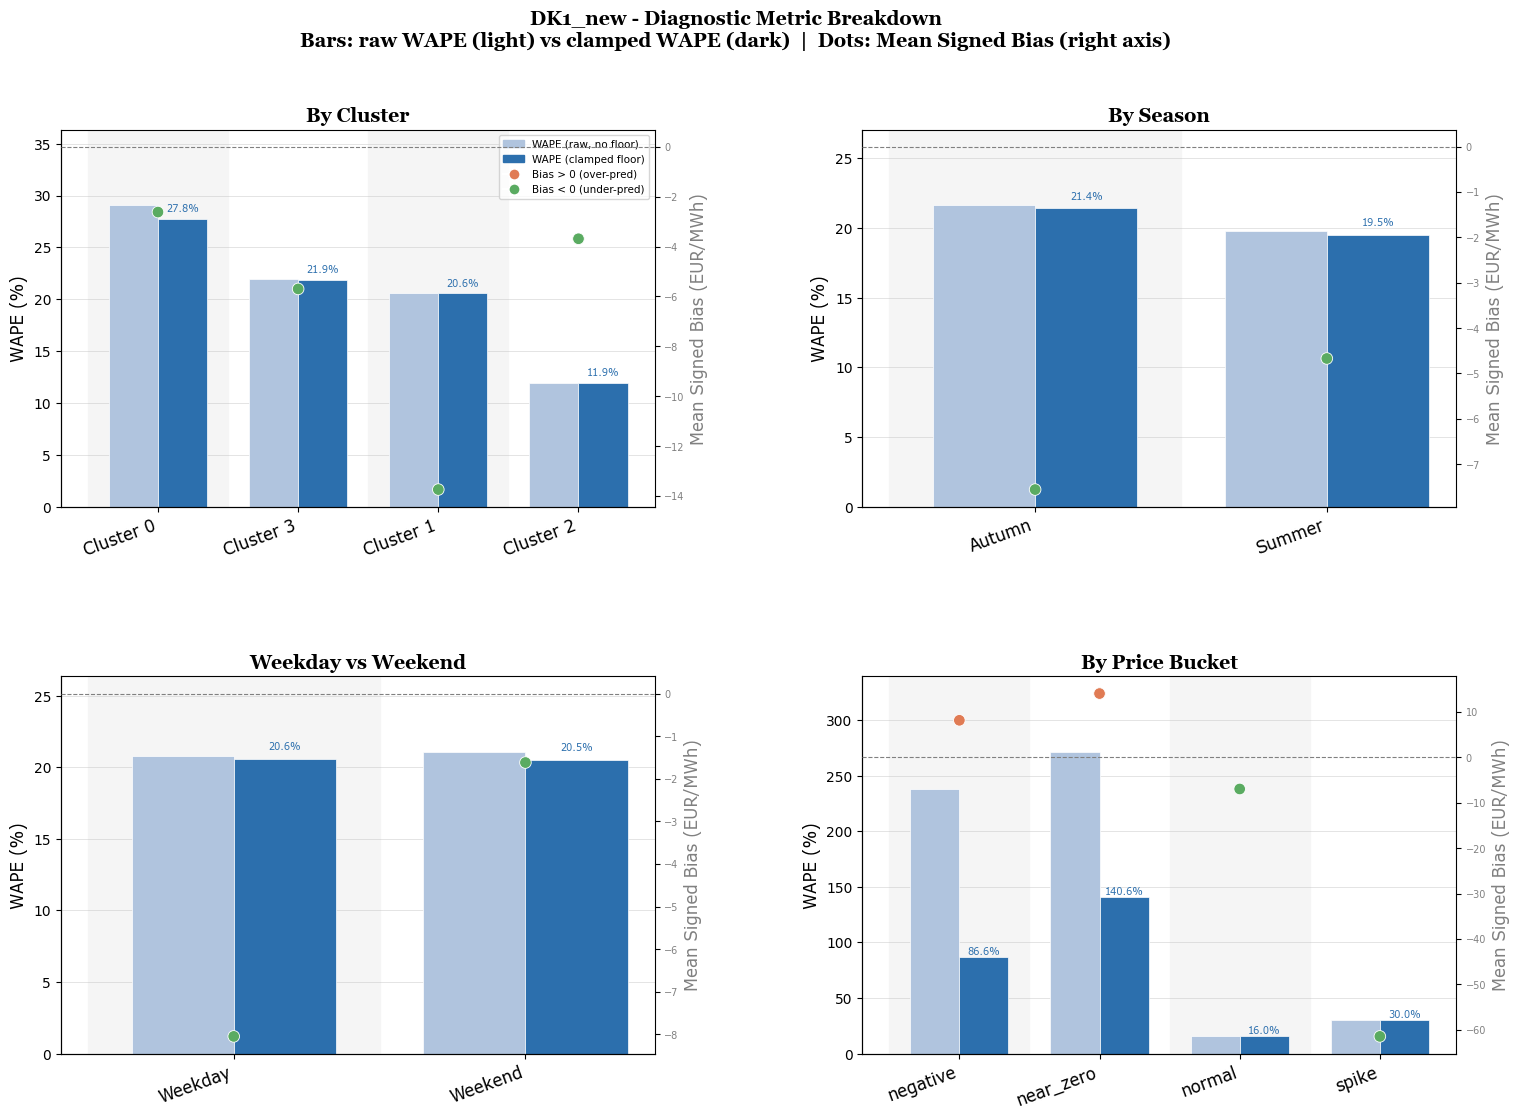

  Figure saved → diagnostic_DK1_new.png

  DIAGNOSTIC SUMMARY - ES_new   (price_floor = 10.0 EUR/MWh)

  ──────────────────────────────────────────────────────────────────────────
  Overall
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  All                      3,837  100.0%    12.65   18.62%    18.28%    -0.18

  ──────────────────────────────────────────────────────────────────────────
  By Cluster
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  Cluster 3          

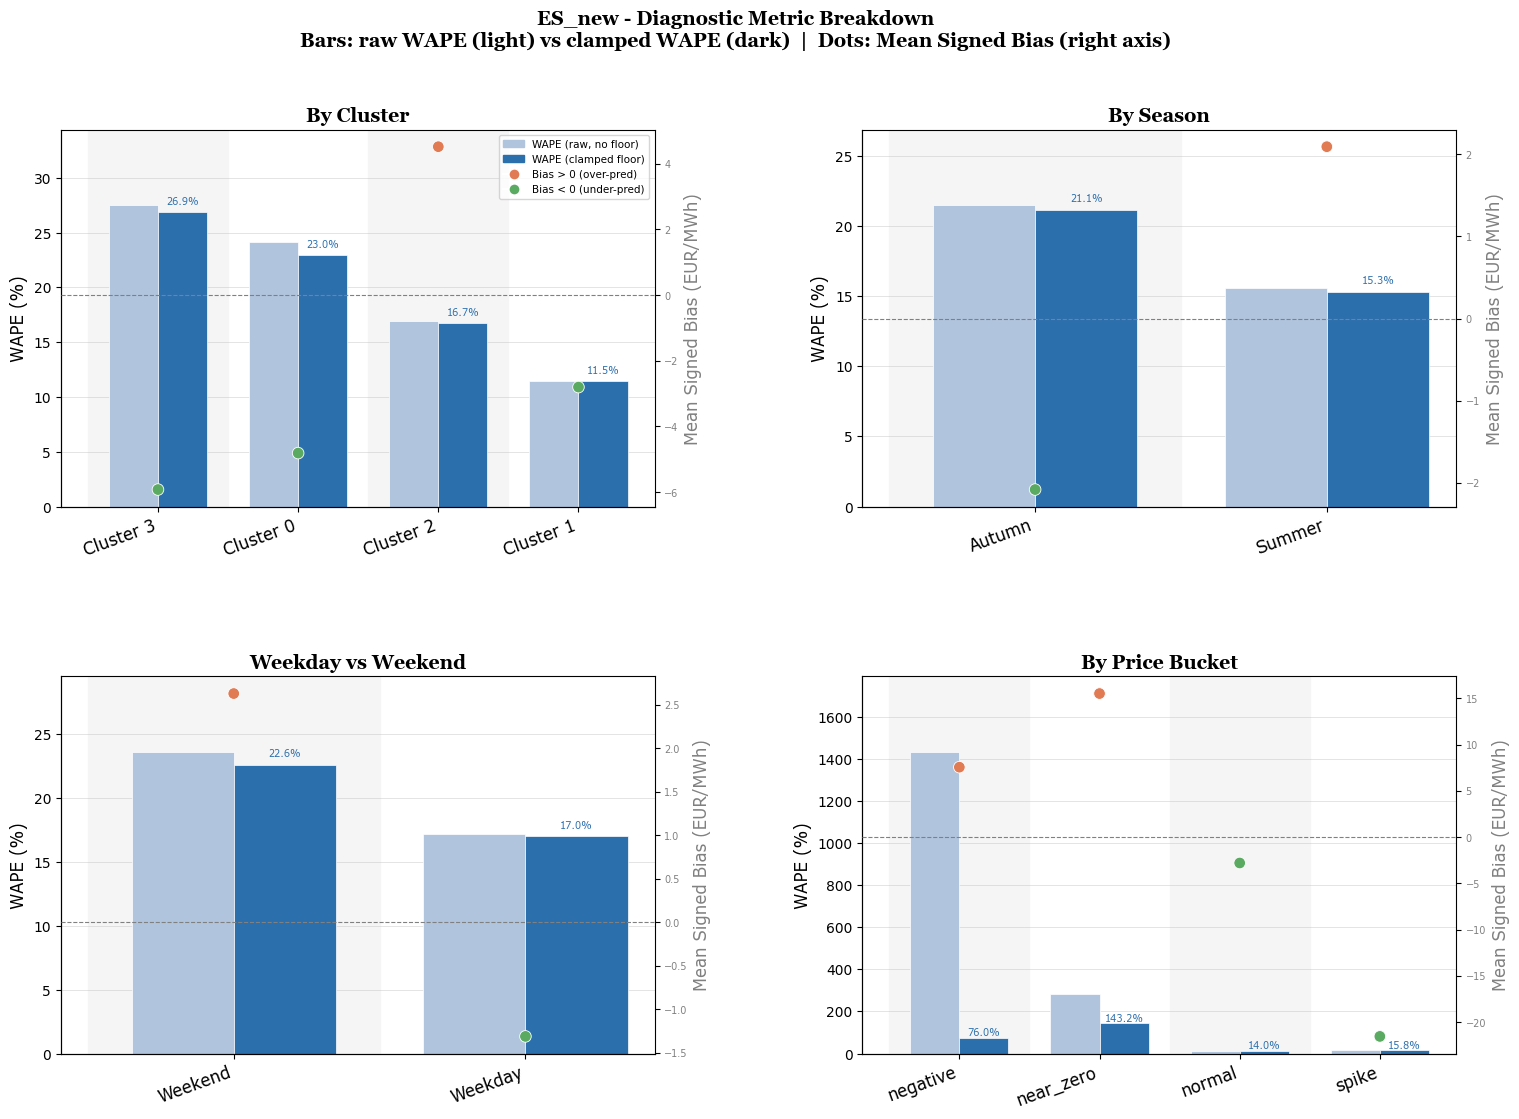

  Figure saved → diagnostic_ES_new.png

  DIAGNOSTIC SUMMARY - NO2_new   (price_floor = 10.0 EUR/MWh)

  ──────────────────────────────────────────────────────────────────────────
  Overall
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  All                      3,837  100.0%     9.89   14.74%    14.66%    -5.24

  ──────────────────────────────────────────────────────────────────────────
  By Cluster
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  Cluster 0          

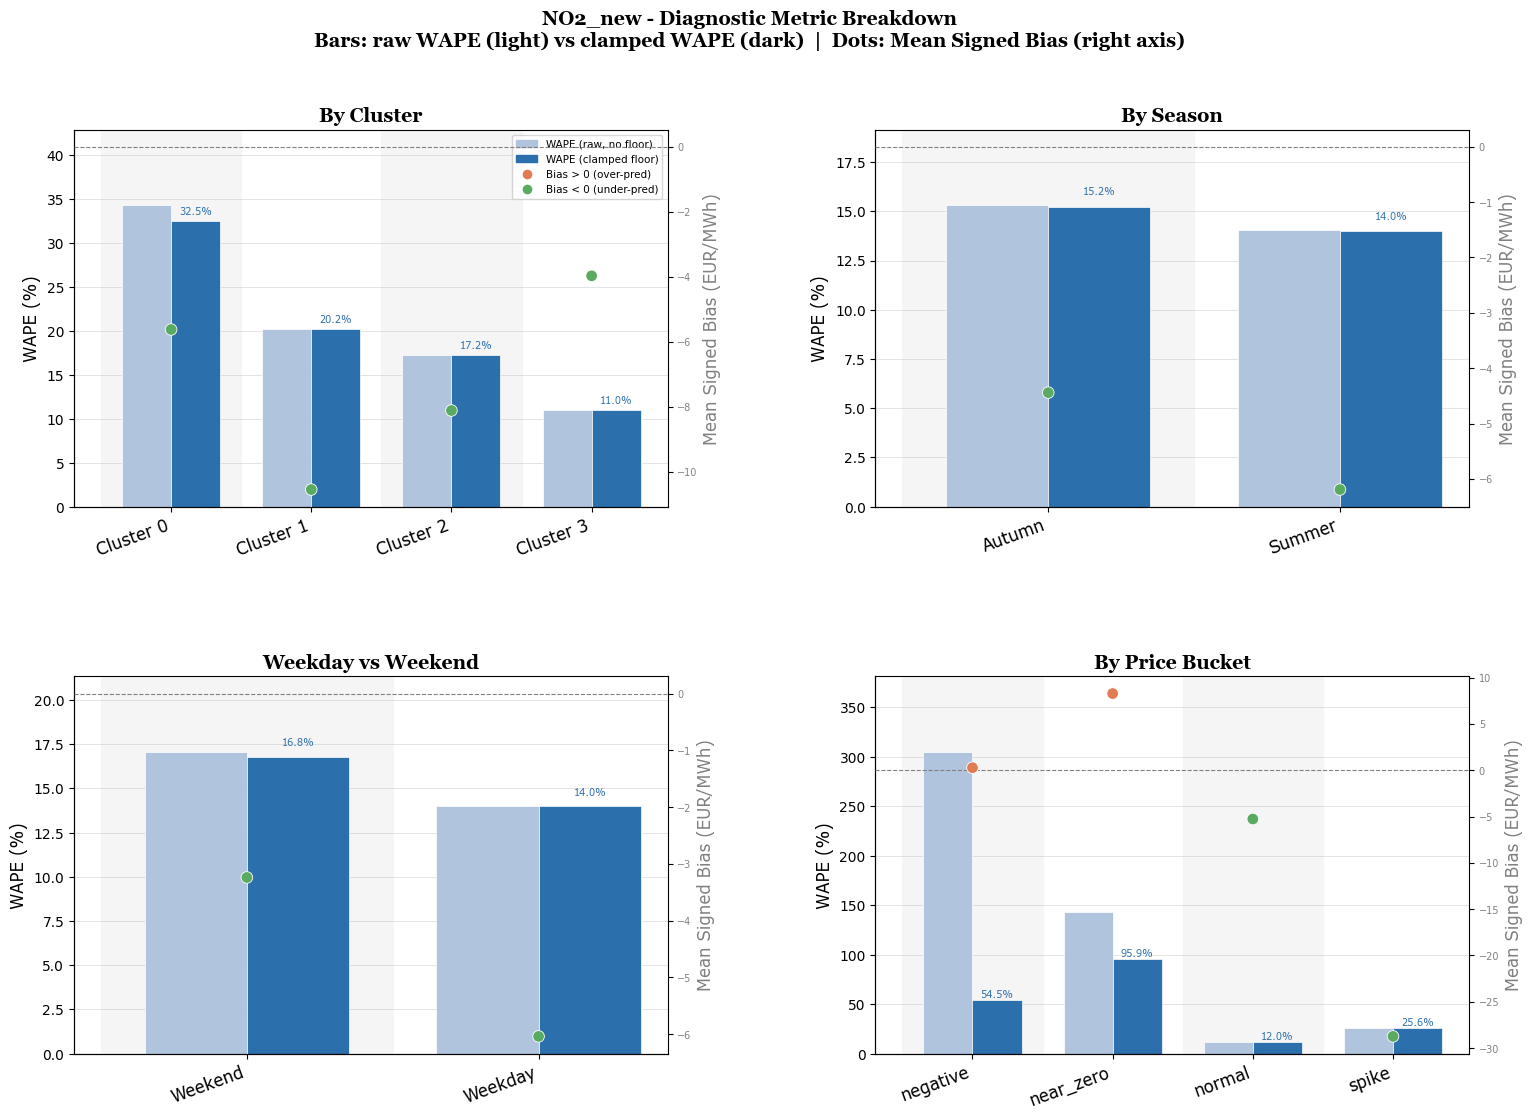

  Figure saved → diagnostic_NO2_new.png
SIGNED BIAS DIAGNOSTICS

▶ Plot A: Hourly bias with confidence band


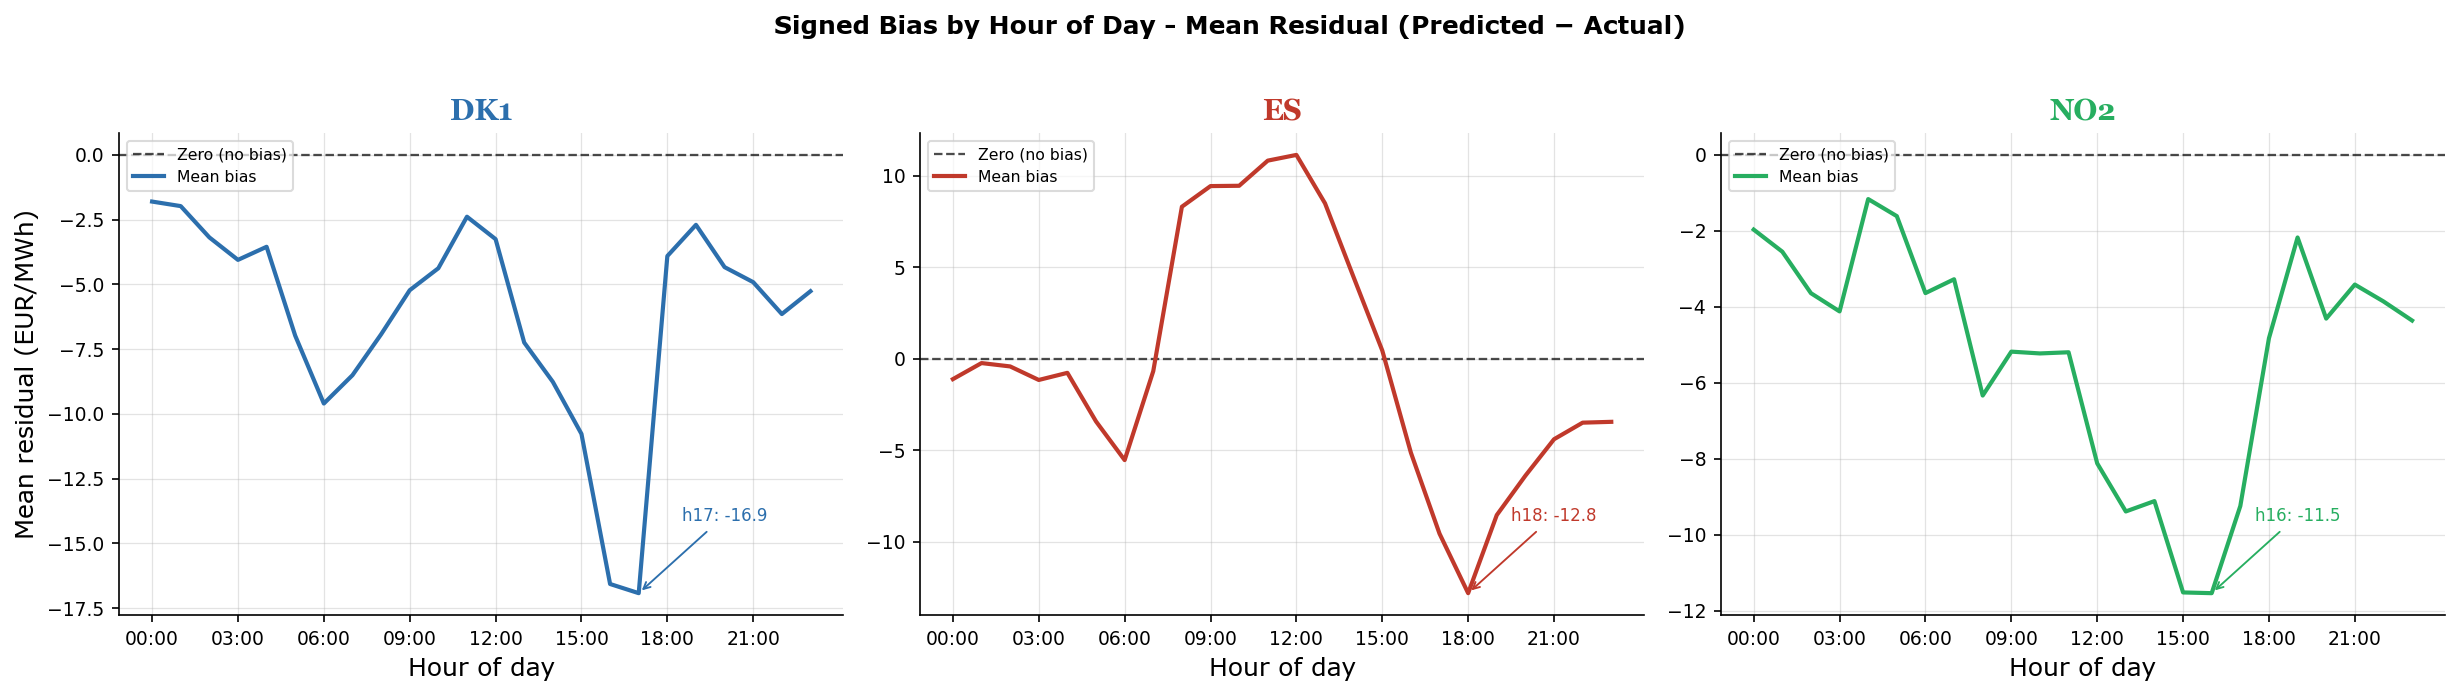

Saved → results\comparison\diag_new_multizone/p2_hourly_bias.png

▶ Plot B: Hour × Price-Bucket


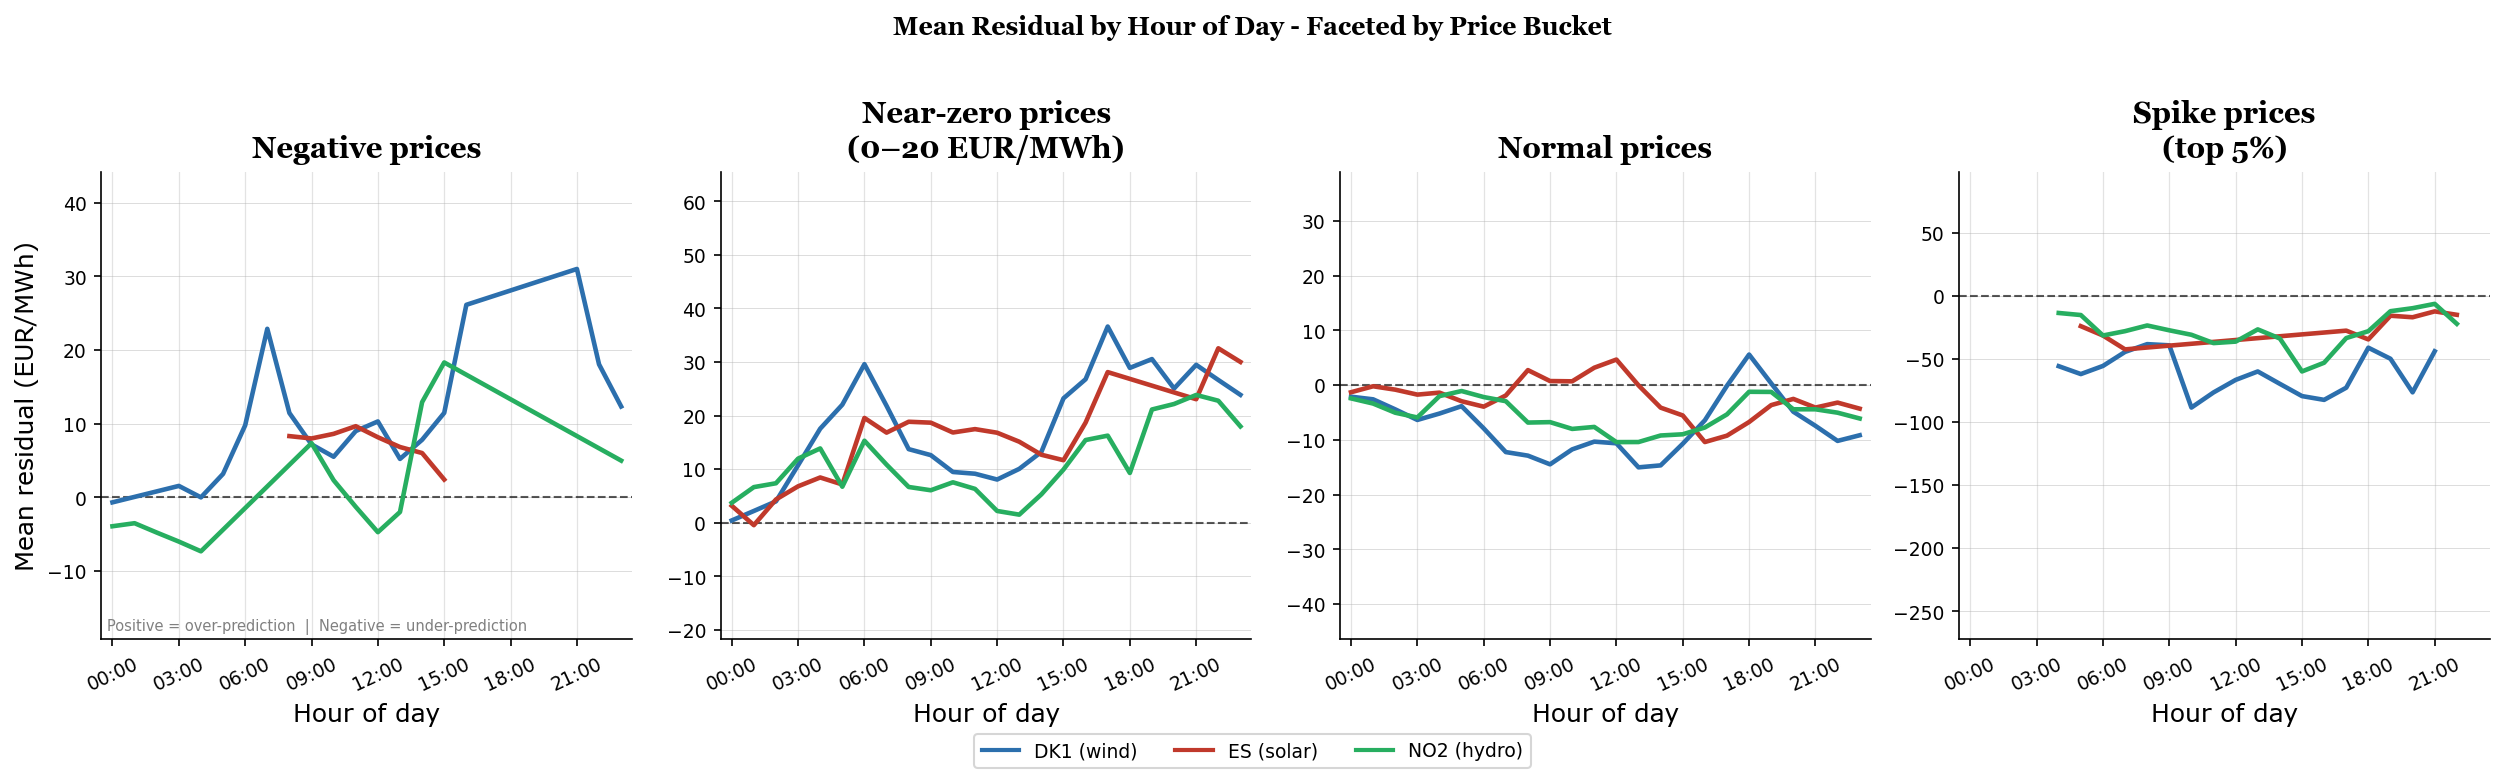

Saved → results\comparison\diag_new_multizone/plot_intraday_residual_by_bucket.png

▶ Table C: Spike hit-rate


,Spike threshold,N hours,Mean residual,Median residual,% under -10 EUR/MWh,% under -20 EUR/MWh,% under -50 EUR/MWh
Zone,,,,,,,
DK1,>146.3 EUR/MWh,195,-61.46,-46.39,85.1%,77.4%,46.2%
ES,>128.1 EUR/MWh,192,-21.55,-17.84,71.9%,45.8%,9.4%
NO2,>98.5 EUR/MWh,192,-28.74,-17.22,72.4%,44.8%,18.8%



▶ Plot C: Spike hit-rate column chart


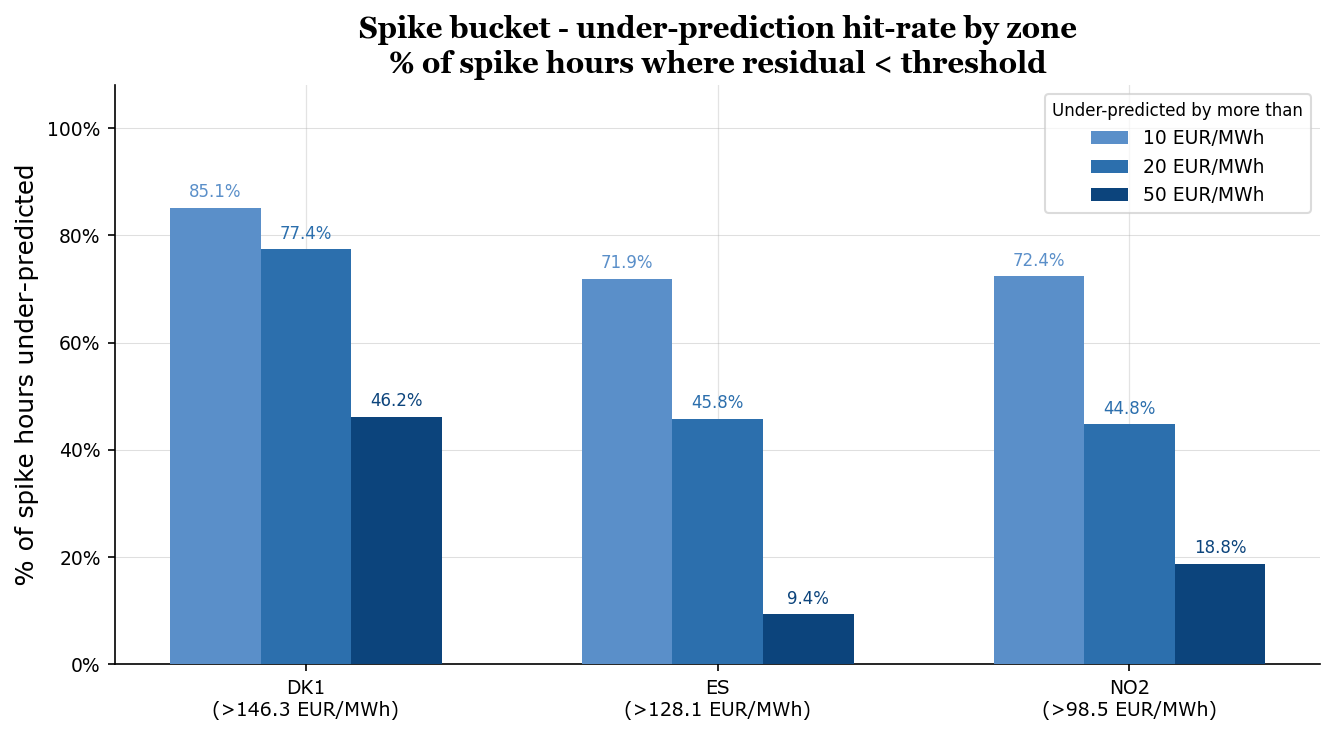

Saved → results\comparison\diag_new_multizone/p2_spike_hit_rate.png

▶ Plot D: Weekday vs Weekend hourly bias


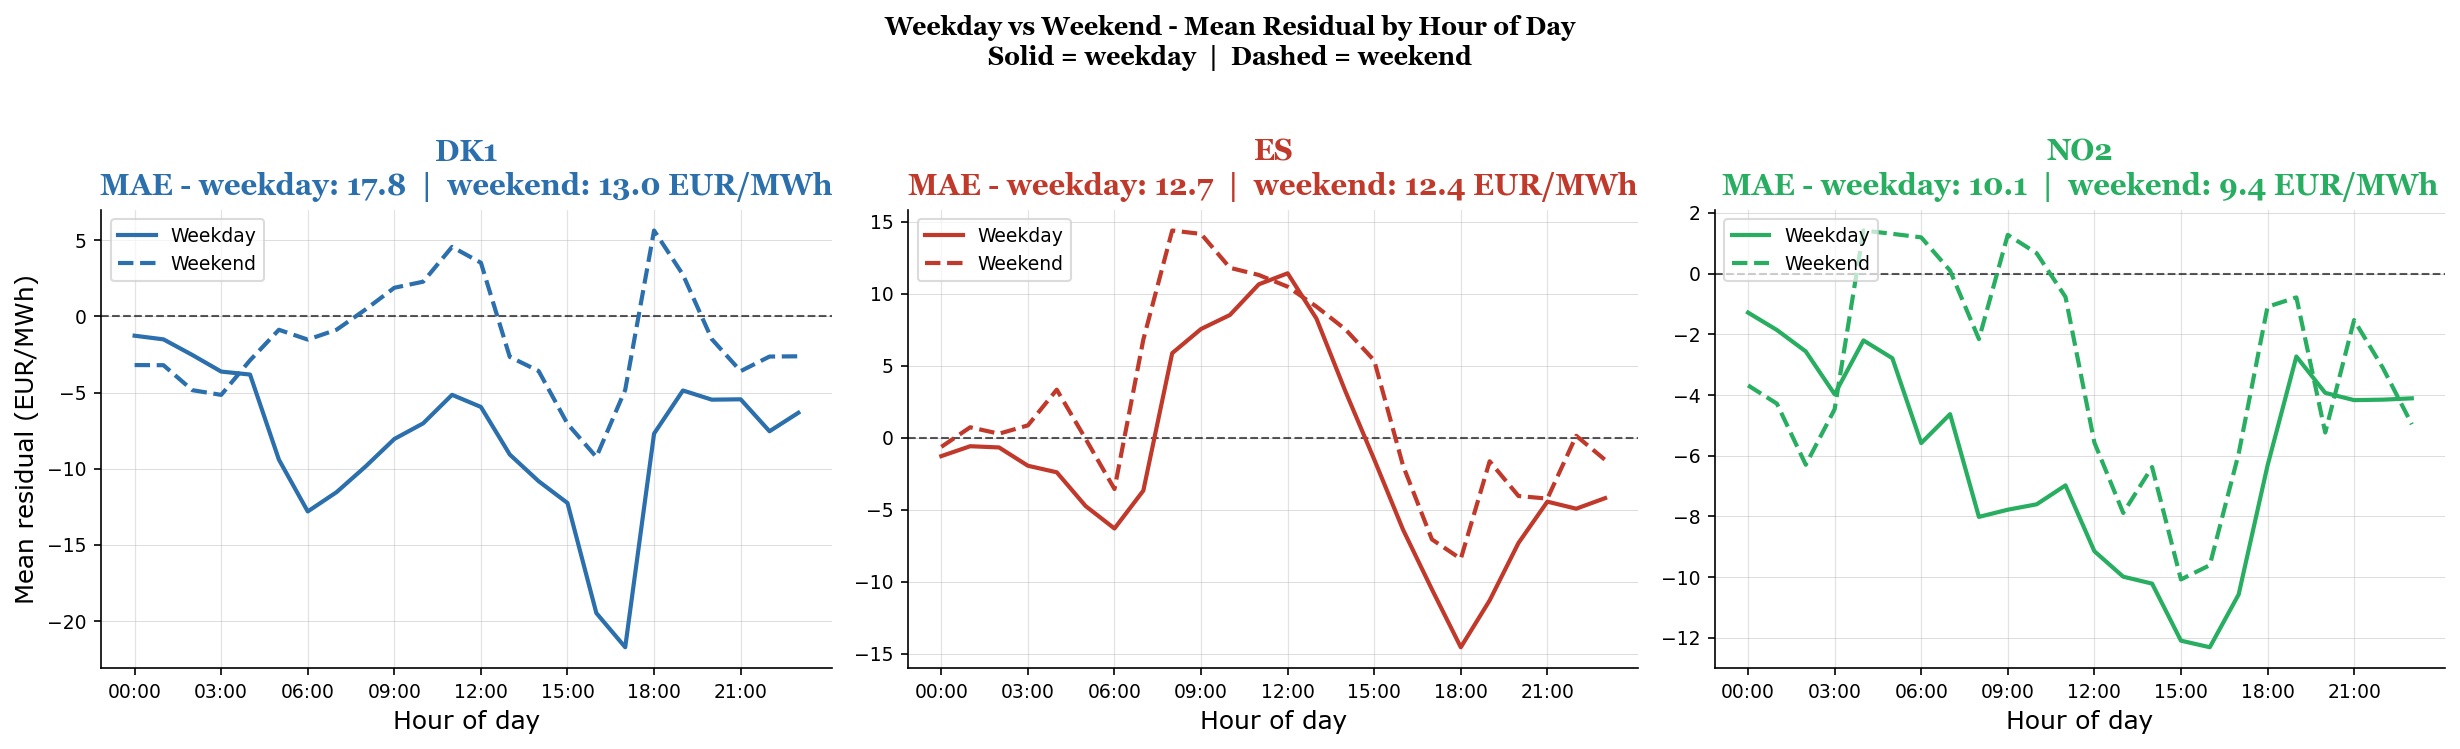

Saved → results\comparison\diag_new_multizone/p2_weekend_weekday.png

  CROSS-ZONE OVERALL COMPARISON
  Zone          MAE      WAPE    WAPE_CL      BIAS
            EUR/MWh         %    % (fld)   EUR/MWh
  --------------------------------------------------------
  DK1         16.45    20.84%     20.57%     -6.23
  ES          12.65    18.62%     18.28%     -0.18
  NO2          9.89    14.74%     14.66%     -5.24



In [8]:
# run diagnostics
out = run_multizone_diagnostics(long_by_zone, SAVE_DIR)


In [9]:
out["cross_zone"]                      # cross-zone comparison table
out["p2_out"]["hit_rate_table"]        # spike hit-rate, one row per zone
for z, s in out["summaries"].items():  # WAPE inflation per zone
    print(z); display(wape_inflation_report(s))

DK1


,dimension,group,n_hours,wape,wape_cl,wape_inflation
0,price_bucket,negative,171,237.73,86.63,151.10
1,price_bucket,near_zero,524,271.37,140.64,130.73


ES


,dimension,group,n_hours,wape,wape_cl,wape_inflation
0,price_bucket,negative,103,1434.35,76.03,1358.32
1,price_bucket,near_zero,688,283.26,143.24,140.02


NO2


,dimension,group,n_hours,wape,wape_cl,wape_inflation
0,price_bucket,negative,30,305.07,54.47,250.60
1,price_bucket,near_zero,326,143.34,95.89,47.45


# Part 2 - price bucket comparison plot needed for final presentation
**we create a plot which compares the raw WAPE between the inherited model and the new model by price regime**

In [10]:
from src.diagnostics_part1 import BUCKET_ORDER,assign_price_bucket, diagnostic_metrics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch



In [11]:

new_bucket_wape = {}
for zone, summary in out["summaries"].items():
    sub = (
        summary[summary["dimension"] == "price_bucket"][["group", "wape"]]
        .set_index("group")
        .reindex(BUCKET_ORDER)
        .reset_index()
    )
    new_bucket_wape[zone] = sub

In [12]:
old_bucket_wape = {}
for zone in ZONES_CMP:
    df_old = globals()[f"old+{zone}+_df"].copy()
    df_old["price_bucket"] = assign_price_bucket(df_old["price_eur_mwh"])

    rows = []
    for bucket in BUCKET_ORDER:
        sub = df_old[df_old["price_bucket"] == bucket].dropna(
            subset=["price_eur_mwh", "weighted_pred_price"]
        )
        if len(sub) == 0:
            rows.append({"group": bucket, "wape": np.nan})
            continue
        m = diagnostic_metrics(sub["price_eur_mwh"].values, sub["weighted_pred_price"].values)
        rows.append({"group": bucket, "wape": m["wape"]})

    old_bucket_wape[zone] = pd.DataFrame(rows)


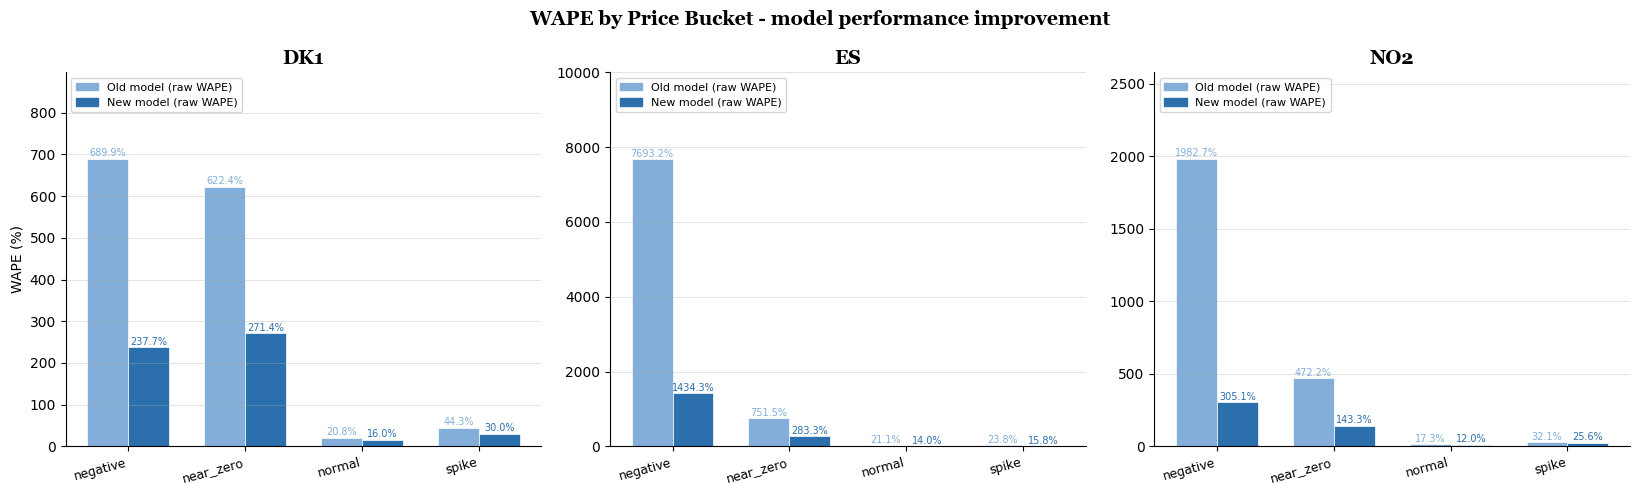

Saved -> results/comparison/wape_bucket_old_vs_new.png


In [13]:

COLOR_OLD = "#82aed9"   # same muted blue used for raw WAPE in diagnostics_part1
COLOR_NEW = "#2c6fad"   # same solid blue used for clamped WAPE

def plot_wape_comparison_by_bucket(
    old_bucket_wape: dict,
    new_bucket_wape: dict,
    zones: list,
    save_path: str = "results/comparison/wape_bucket_old_vs_new.png",
) -> None:
    n = len(zones)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]

    fig.suptitle(
        "WAPE by Price Bucket - model performance improvement",
        fontsize=14, fontweight="bold", y=0.98, fontname = "Georgia"
    )

    for ax, zone in zip(axes, zones):
        old_df = old_bucket_wape[zone]
        new_df = new_bucket_wape[zone]

        x     = np.arange(len(BUCKET_ORDER))
        width = 0.35

        bars_old = ax.bar(
            x - width / 2, old_df["wape"], width,
            color=COLOR_OLD, edgecolor="white", linewidth=0.5, label="Old model",
             
        )
        bars_new = ax.bar(
            x + width / 2, new_df["wape"], width,
            color=COLOR_NEW, edgecolor="white", linewidth=0.5, label="New model",
         
        )

        # Value labels
        for bars in [bars_old, bars_new]:
            for bar in bars:
                h = bar.get_height()
                if pd.notna(h):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 1.0, f"{h:.1f}%",
                        ha="center", va="bottom", fontsize=7,
                        color=bar.get_facecolor(),
                    )

        ax.set_title(zone, fontsize=14, fontweight="bold", fontname="Georgia")
        ax.set_ylabel("WAPE (%)" if zone == zones[0] else "")
        ax.set_xticks(x)
        ax.set_xticklabels(BUCKET_ORDER, rotation=15, ha="right", fontsize=9, fontname = "Verdana")
        ax.set_ylim(0, max(
            old_df["wape"].max(skipna=True),
            new_df["wape"].max(skipna=True),
        ) * 1.3)
        ax.grid(axis="y", linewidth=0.4, alpha=0.6)
        ax.spines[["top", "right"]].set_visible(False)

        
        ax.legend(handles=[
            Patch(color=COLOR_OLD, label="Old model (raw WAPE)"),
            Patch(color=COLOR_NEW, label="New model (raw WAPE)"),
        ], fontsize=8, loc="upper left")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {save_path}")

plot_wape_comparison_by_bucket(old_bucket_wape, new_bucket_wape, ZONES_CMP)